PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING


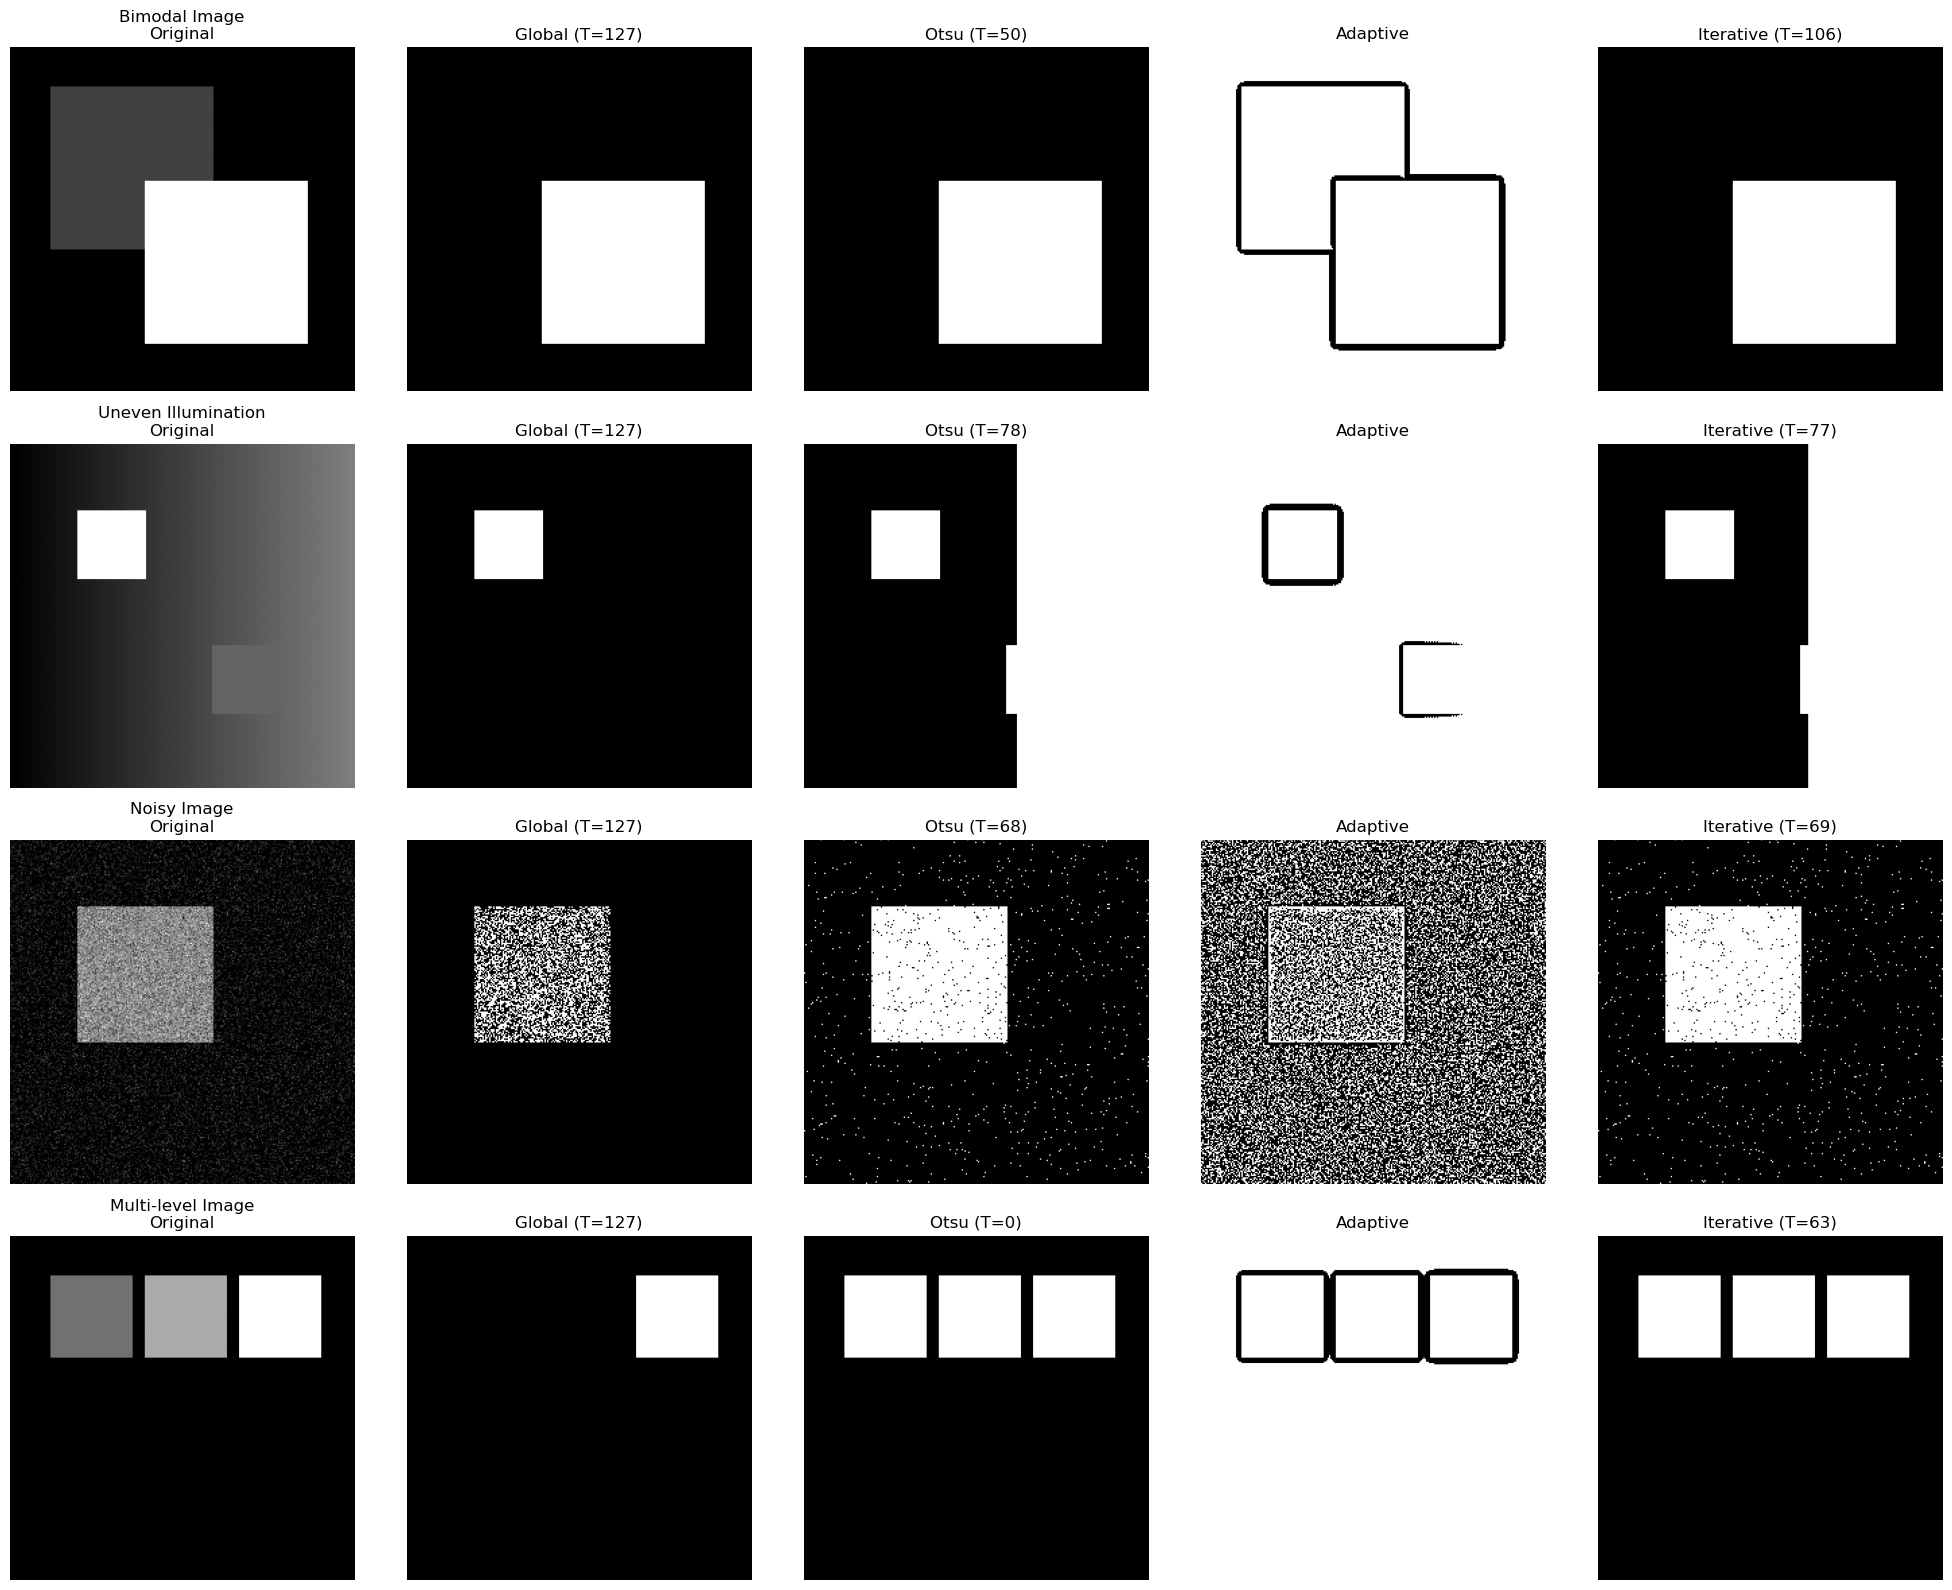


ANALISIS HISTOGRAM DAN THRESHOLD SELECTION
------------------------------------------------------------


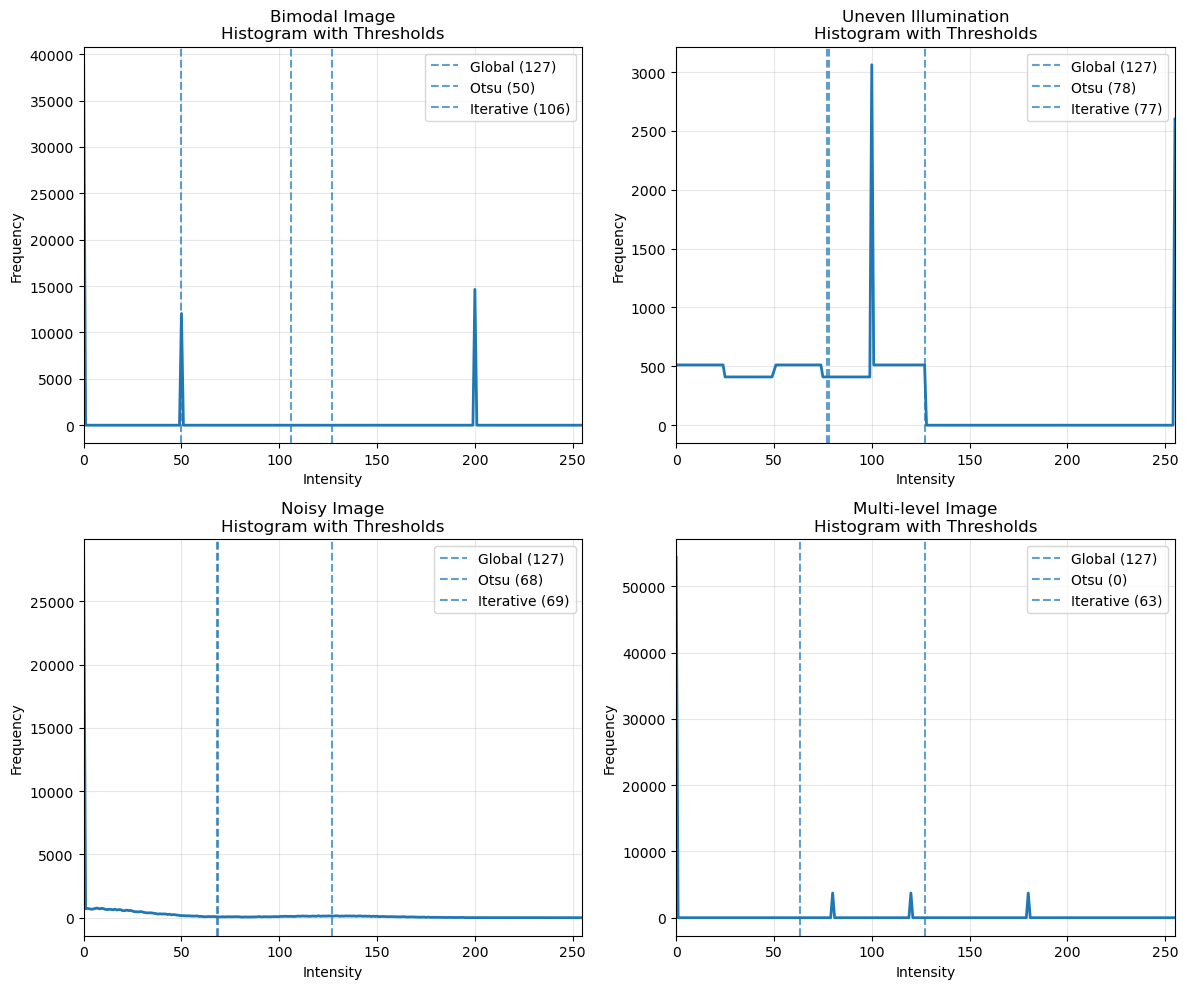


KESIMPULAN DAN REKOMENDASI
----------------------------------------

1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform

2. Otsu's Method:
   - Automatic, optimal untuk histogram bimodal

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination

4. Iterative Thresholding:
   - Self-adaptive tapi lebih mahal komputasi
    


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

def praktikum_9_1():
    """
    Perbandingan teknik thresholding: Global, Otsu, dan Adaptive
    """
    print("PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING")
    print("=" * 60)
    
    def create_test_images():
        images = {}
        
        img_bimodal = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_bimodal, (30, 30), (150, 150), 50, -1)
        cv2.rectangle(img_bimodal, (100, 100), (220, 220), 200, -1)
        images['Bimodal Image'] = img_bimodal
        
        img_uneven = np.zeros((256, 256), dtype=np.uint8)
        for i in range(256):
            img_uneven[:, i] = i // 2
        cv2.rectangle(img_uneven, (50, 50), (100, 100), 255, -1)
        cv2.rectangle(img_uneven, (150, 150), (200, 200), 100, -1)
        images['Uneven Illumination'] = img_uneven
        
        img_noisy = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_noisy, (50, 50), (150, 150), 128, -1)
        noise = np.random.normal(0, 30, img_noisy.shape)
        img_noisy = np.clip(img_noisy.astype(float) + noise, 0, 255).astype(np.uint8)
        images['Noisy Image'] = img_noisy
        
        img_multi = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_multi, (30, 30), (90, 90), 80, -1)
        cv2.rectangle(img_multi, (100, 30), (160, 90), 120, -1)
        cv2.rectangle(img_multi, (170, 30), (230, 90), 180, -1)
        images['Multi-level Image'] = img_multi
        
        return images
    
    def apply_global_threshold(image, T=127):
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary
    
    def apply_otsu_threshold(image):
        _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary
    
    def apply_adaptive_threshold(image, block_size=11, C=2):
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, block_size, C)
        return binary
    
    def apply_iterative_threshold(image, max_iter=100, tolerance=1):
        T = np.mean(image)
        
        for i in range(max_iter):
            foreground = image[image > T]
            background = image[image <= T]
            
            if len(foreground) > 0 and len(background) > 0:
                mu_fg = np.mean(foreground)
                mu_bg = np.mean(background)
                T_new = (mu_fg + mu_bg) / 2
                
                if abs(T_new - T) < tolerance:
                    T = T_new
                    break
                    
                T = T_new
            else:
                break
        
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary, T
    
    test_images = create_test_images()
    results = {}
    
    for name, image in test_images.items():
        gray = image.copy()
        
        global_binary = apply_global_threshold(gray, 127)
        otsu_binary = apply_otsu_threshold(gray)
        adaptive_binary = apply_adaptive_threshold(gray, 11, 2)
        iterative_binary, T_iter = apply_iterative_threshold(gray)
        
        # ✅ FIX OTSU (ambil scalar threshold)
        T_otsu, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        results[name] = {
            'original': gray,
            'global': global_binary,
            'otsu': otsu_binary,
            'adaptive': adaptive_binary,
            'iterative': iterative_binary,
            'T_otsu': T_otsu,
            'T_iter': T_iter  # ✅ FIX (langsung scalar)
        }
    
    fig, axes = plt.subplots(len(test_images), 5, figsize=(20, 4*len(test_images)))
    
    for idx, (name, result) in enumerate(results.items()):
        axes[idx, 0].imshow(result['original'], cmap='gray')
        axes[idx, 0].set_title(f'{name}\nOriginal')
        axes[idx, 0].axis('off')
        
        methods = ['global', 'otsu', 'adaptive', 'iterative']
        titles = [
            'Global (T=127)',
            f'Otsu (T={result["T_otsu"]:.0f})',
            'Adaptive',
            f'Iterative (T={result["T_iter"]:.0f})'
        ]
        
        for col, (method, title) in enumerate(zip(methods, titles), 1):
            axes[idx, col].imshow(result[method], cmap='gray')
            axes[idx, col].set_title(title)
            axes[idx, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nANALISIS HISTOGRAM DAN THRESHOLD SELECTION")
    print("-" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    for idx, (name, result) in enumerate(list(results.items())[:4]):
        hist = cv2.calcHist([result['original']], [0], None, [256], [0, 256])
        axes[idx].plot(hist, linewidth=2)
        
        axes[idx].axvline(x=127, linestyle='--', label='Global (127)', alpha=0.7)
        axes[idx].axvline(x=result['T_otsu'], linestyle='--',
                         label=f'Otsu ({result["T_otsu"]:.0f})', alpha=0.7)
        axes[idx].axvline(x=result['T_iter'], linestyle='--',
                         label=f'Iterative ({result["T_iter"]:.0f})', alpha=0.7)
        
        axes[idx].set_title(f'{name}\nHistogram with Thresholds')
        axes[idx].set_xlabel('Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0, 255])
    
    plt.tight_layout()
    plt.show()
    
    print("\nKESIMPULAN DAN REKOMENDASI")
    print("-" * 40)
    print("""
1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform

2. Otsu's Method:
   - Automatic, optimal untuk histogram bimodal

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination

4. Iterative Thresholding:
   - Self-adaptive tapi lebih mahal komputasi
    """)
    
    return results

thresholding_results = praktikum_9_1()


PRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION


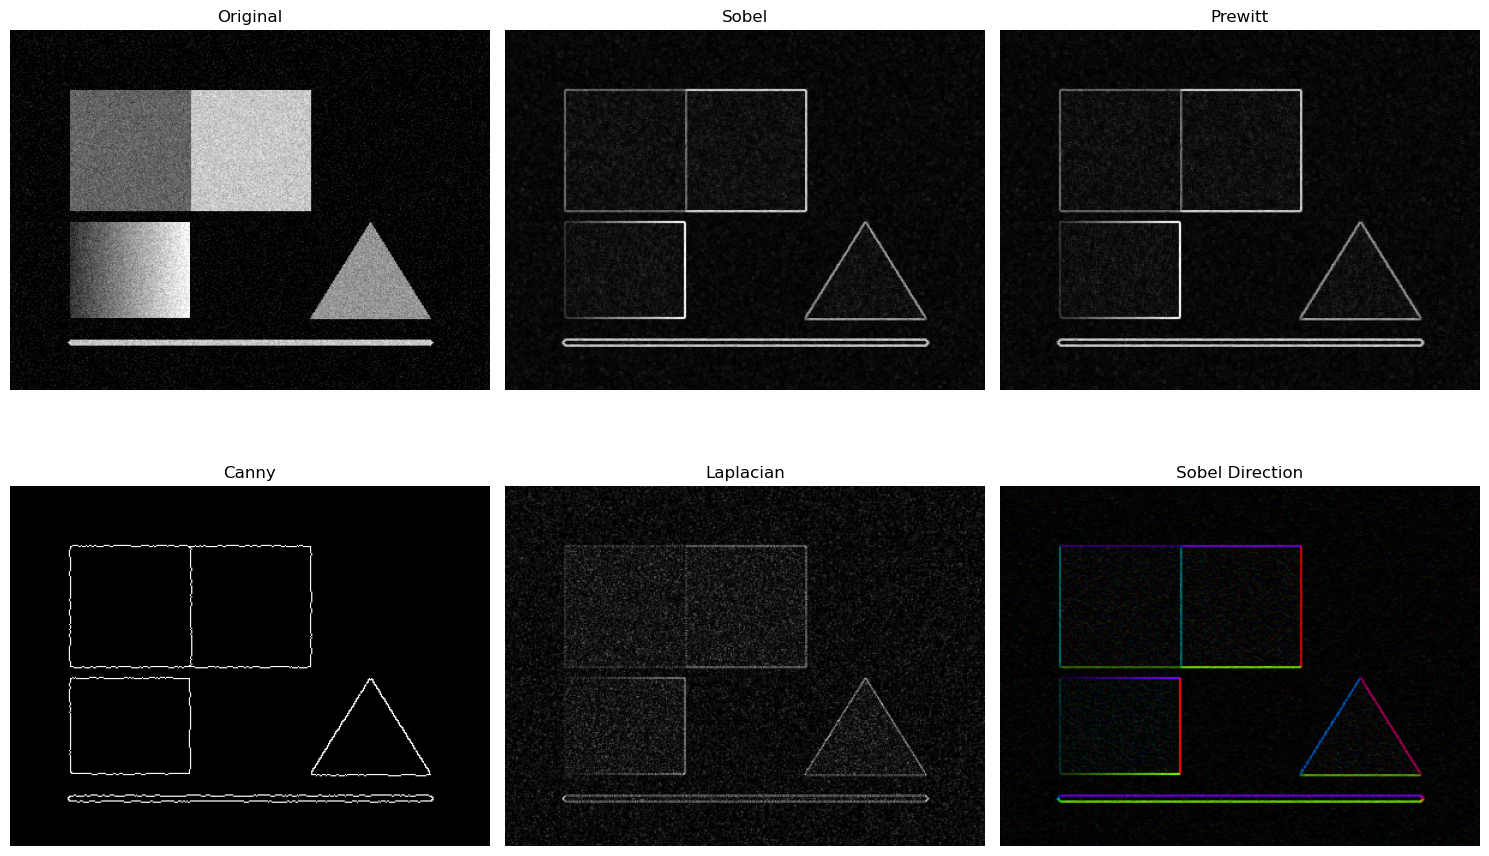

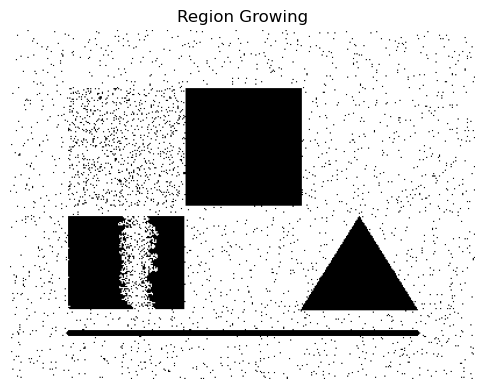


KESIMPULAN:

- Canny paling robust terhadap noise
- Sobel/Prewitt bagus untuk analisis gradien
- Region Growing sensitif terhadap seed & threshold



In [4]:
def praktikum_9_2():
    print("\nPRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION")
    print("=" * 70)
    
    def create_edge_test_image():
        img = np.zeros((300, 400), dtype=np.uint8)

        cv2.rectangle(img, (50, 50), (150, 150), 100, -1)
        cv2.rectangle(img, (151, 50), (250, 150), 200, -1)

        for i in range(50, 150):
            img[160:240, i] = 50 + (i - 50) * 2

        triangle_cnt = np.array([(300, 160), (350, 240), (250, 240)])
        cv2.drawContours(img, [triangle_cnt], 0, 150, -1)

        cv2.line(img, (50, 260), (350, 260), 200, 3)

        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

        return img

    def apply_sobel_edge_detection(image):
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1)

        magnitude = np.sqrt(sobelx**2 + sobely**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        direction = np.arctan2(sobely, sobelx) * 180 / np.pi
        return magnitude.astype(np.uint8), direction

    def apply_prewitt_edge_detection(image):
        kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
        kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

        gx = cv2.filter2D(image.astype(np.float64), -1, kernelx)
        gy = cv2.filter2D(image.astype(np.float64), -1, kernely)

        mag = np.sqrt(gx**2 + gy**2)
        mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

        return mag.astype(np.uint8)

    def apply_canny_edge_detection(image):
        blurred = cv2.GaussianBlur(image, (5,5), 1.4)
        return cv2.Canny(blurred, 50, 150)

    def apply_laplacian_edge_detection(image):
        lap = cv2.Laplacian(image, cv2.CV_64F)
        lap = np.abs(lap)
        lap = cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX)
        return lap.astype(np.uint8)

    def region_growing_segmentation(image, seeds, threshold=20):
        h, w = image.shape
        segmented = np.zeros_like(image)
        visited = np.zeros_like(image, dtype=bool)

        for seed in seeds:
            x, y = seed
            if x >= h or y >= w:
                continue

            stack = [(x, y)]
            region_pixels = []

            while stack:
                x, y = stack.pop()

                if visited[x, y]:
                    continue

                visited[x, y] = True
                region_pixels.append(image[x, y])
                segmented[x, y] = 255

                mean_val = np.mean(region_pixels)

                for nx, ny in [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]:
                    if 0 <= nx < h and 0 <= ny < w:
                        if not visited[nx, ny]:
                            if abs(int(image[nx, ny]) - mean_val) < threshold:
                                stack.append((nx, ny))

        return segmented

    test_image = create_edge_test_image()

    sobel_mag, sobel_dir = apply_sobel_edge_detection(test_image)
    prewitt = apply_prewitt_edge_detection(test_image)
    canny = apply_canny_edge_detection(test_image)
    laplacian = apply_laplacian_edge_detection(test_image)

    # FIX seed (yang out of bound diganti)
    seeds = [(75,100), (200,100), (250,200)]

    region_grown = region_growing_segmentation(test_image, seeds, 25)

    # ================= VISUALISASI =================
    fig, axes = plt.subplots(2,3, figsize=(15,10))

    axes[0,0].imshow(test_image, cmap='gray')
    axes[0,0].set_title("Original")

    axes[0,1].imshow(sobel_mag, cmap='gray')
    axes[0,1].set_title("Sobel")

    axes[0,2].imshow(prewitt, cmap='gray')
    axes[0,2].set_title("Prewitt")

    axes[1,0].imshow(canny, cmap='gray')
    axes[1,0].set_title("Canny")

    axes[1,1].imshow(laplacian, cmap='gray')
    axes[1,1].set_title("Laplacian")

    # FIX HSV
    hsv = np.zeros((test_image.shape[0], test_image.shape[1],3), dtype=np.uint8)
    hsv[...,0] = ((sobel_dir + 180) / 2).astype(np.uint8)
    hsv[...,1] = 255
    hsv[...,2] = sobel_mag

    axes[1,2].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    axes[1,2].set_title("Sobel Direction")

    for ax in axes.ravel():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # ================= REGION =================
    plt.figure(figsize=(6,6))
    plt.imshow(region_grown, cmap='gray')
    plt.title("Region Growing")
    plt.axis('off')
    plt.show()

    print("\nKESIMPULAN:")
    print("""
- Canny paling robust terhadap noise
- Sobel/Prewitt bagus untuk analisis gradien
- Region Growing sensitif terhadap seed & threshold
""")

    return test_image, {
        "Sobel": sobel_mag,
        "Prewitt": prewitt,
        "Canny": canny,
        "Laplacian": laplacian
    }, {
        "Region Growing": region_grown
    }

# RUN
edge_test_image, edge_results, region_results = praktikum_9_2()